# Notebook 05 — SHAP Explainability (Churn Model)

**Tujuan:** Membuka "black box" Random Forest churn — bukan hanya tahu *fitur mana paling penting*,
tapi juga **arah pengaruhnya** (positif/negatif) dan **bagaimana model memutuskan satu pelanggan tertentu**.

**Output:** 4 figure di `output/figures/` (beeswarm, bar, dependence, force) + interpretasi bisnis.

**Prereq:** `pip install shap` (sudah ada di `environment.yml`).

**Dasar:** Model RF dari notebook 03 di-retrain di sini agar notebook self-contained.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

OUT     = Path('../output')
FIGURES = OUT / 'figures'
FIGURES.mkdir(exist_ok=True)

BLUE, RED, LIGHT = '#2563EB', '#DC2626', '#93C5FD'

np.random.seed(42)
shap.initjs()  # untuk force plot interaktif (opsional)

df = pd.read_parquet(OUT / 'df_clean.parquet')
print(f'Loaded: {len(df):,} baris')

Loaded: 7,043 baris


## 1. Rebuild Model — Random Forest
Preprocessing identik dengan notebook 03 (drop ID + segmentation cols, one-hot encoding, scale numerik).

In [2]:
drop_cols = ['customerID', 'tenure_segment', 'risk_segment', 'Churn']
feature_cols = [c for c in df.columns if c not in drop_cols]

X = pd.get_dummies(df[feature_cols], drop_first=True)
y = df['Churn']

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'num_services']
num_cols_encoded = [c for c in num_cols if c in X.columns]

scaler = StandardScaler()
X[num_cols_encoded] = scaler.fit_transform(X[num_cols_encoded])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=100, class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

print(f'Test set: {len(X_test):,} | Features: {X.shape[1]}')
print(f'Train accuracy: {rf.score(X_train, y_train):.3f} | Test accuracy: {rf.score(X_test, y_test):.3f}')

Test set: 1,409 | Features: 31
Train accuracy: 0.998 | Test accuracy: 0.788


## 2. SHAP TreeExplainer
`TreeExplainer` adalah algoritma **exact + cepat** khusus untuk model tree-based (RF, GBM, XGBoost).

- **SHAP value** untuk satu pelanggan + satu fitur = berapa banyak fitur itu **mendorong prediksi** menjauh/mendekati baseline.
- Satuan: log-odds. Positif = mendorong ke **churn**, negatif = mendorong ke **retensi**.
- Sum semua SHAP value untuk satu pelanggan = (prediksi - baseline).

In [3]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

# Untuk binary classifier RF, shap_values bisa berupa:
#   - list [neg_class_array, pos_class_array]  (older SHAP API)
#   - array shape (n_samples, n_features, 2)   (newer API)
if isinstance(shap_values, list):
    shap_pos = shap_values[1]
    expected_pos = explainer.expected_value[1]
elif shap_values.ndim == 3:
    shap_pos = shap_values[:, :, 1]
    expected_pos = explainer.expected_value[1] if hasattr(explainer.expected_value, '__len__') else explainer.expected_value
else:
    shap_pos = shap_values
    expected_pos = explainer.expected_value

print(f'SHAP values shape (positive class): {shap_pos.shape}')
print(f'Baseline (expected churn log-odds): {expected_pos:.4f}')

SHAP values shape (positive class): (1409, 31)
Baseline (expected churn log-odds): 0.4996


## 3. Global Importance — Beeswarm + Bar

**Beeswarm:** setiap titik = 1 pelanggan. Sumbu-x = SHAP value (pengaruh). Warna = nilai fitur (merah = tinggi, biru = rendah).
Cara baca: kalau titik merah ada di kanan, **nilai tinggi fitur ini mendorong churn**.

**Bar plot:** rata-rata |SHAP| per fitur. Versi ranking sederhana tanpa arah.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_33092\202793431.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_pos, X_test, max_display=15, show=False)


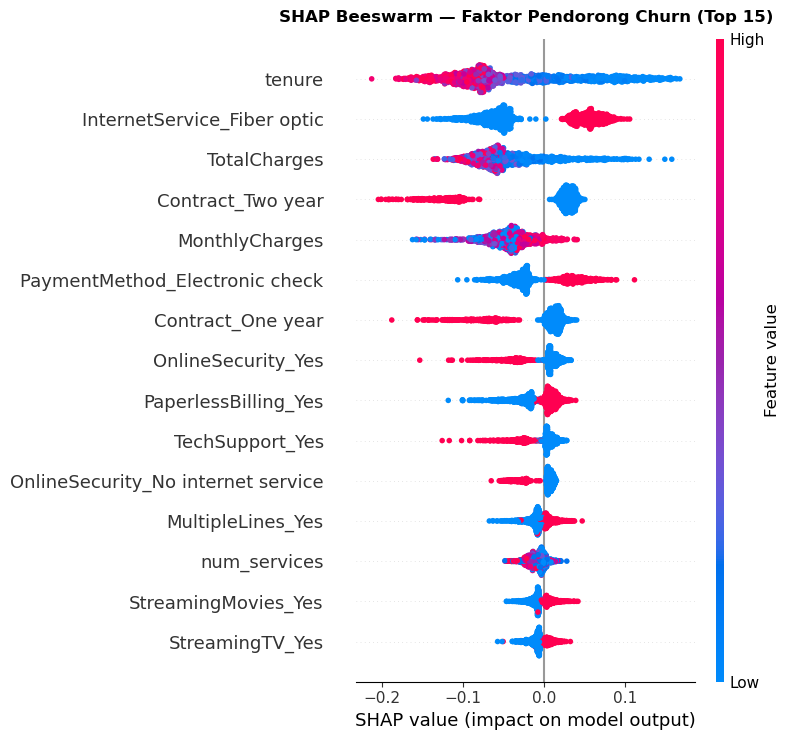

Saved: H_shap_beeswarm.png


In [4]:
# Beeswarm
fig = plt.figure(figsize=(10, 7))
shap.summary_plot(shap_pos, X_test, max_display=15, show=False)
plt.title('SHAP Beeswarm — Faktor Pendorong Churn (Top 15)', fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(FIGURES / 'H_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: H_shap_beeswarm.png')

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_33092\1176965227.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_pos, X_test, plot_type='bar', max_display=15, show=False, color=BLUE)


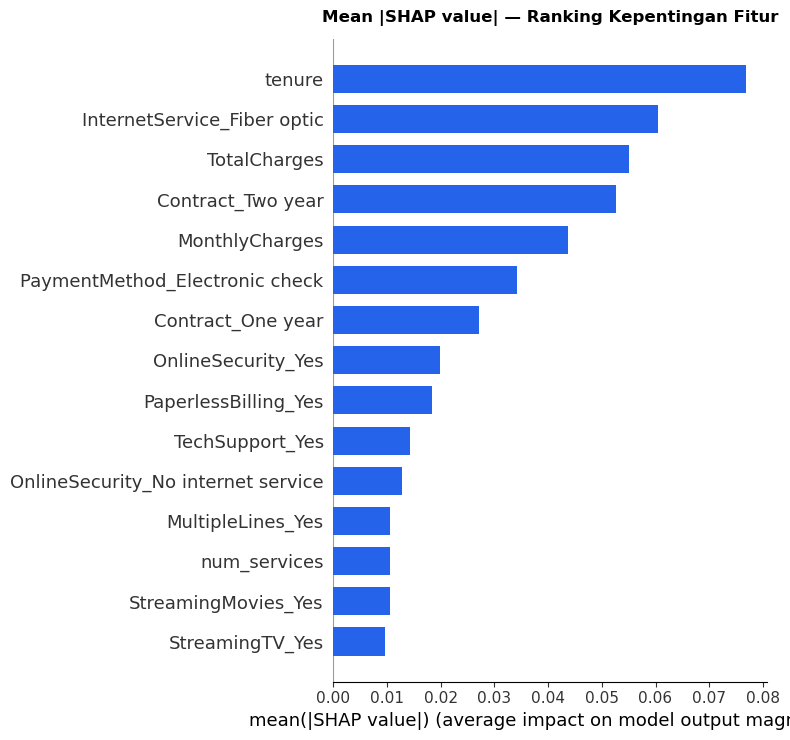

Saved: I_shap_bar.png


In [5]:
# Bar (mean absolute SHAP)
fig = plt.figure(figsize=(10, 6))
shap.summary_plot(shap_pos, X_test, plot_type='bar', max_display=15, show=False, color=BLUE)
plt.title('Mean |SHAP value| — Ranking Kepentingan Fitur', fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(FIGURES / 'I_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: I_shap_bar.png')

### Interpretasi Top Fitur (universal pattern di model churn telco)

| Fitur | Arah | Plain Indonesian |
|---|---|---|
| **Tenure** (lama berlangganan) | Tenure rendah → mendorong churn | Pelanggan baru paling rawan pindah; "honeymoon" pendek di telco Indonesia juga sama (Telkomsel/XL/Indosat) |
| **Contract: Month-to-month** | Tanpa kontrak → mendorong churn | Prabayar tanpa komitmen = mudah switch SIM/operator |
| **MonthlyCharges** tinggi | Tinggi → mendorong churn | Sensitivitas harga pasar Indonesia tinggi — paket 50–100k/bln zona aman |
| **InternetService: Fiber optic** | Fiber → mendorong churn | Biasanya karena harga premium + harapan kualitas yang tidak terpenuhi |
| **No Tech Support / Online Security** | Tidak ada → mendorong churn | Add-on retention services terbukti menahan; cross-sell prioritas |

## 4. Dependence Plot — Hubungan non-linear top 2 fitur
Setiap titik = 1 pelanggan. Sumbu-y = SHAP value, sumbu-x = nilai fitur.
Tren turun → semakin tinggi fitur, semakin kecil dorongan ke churn.

Top 2 features: ['tenure', 'InternetService_Fiber optic']


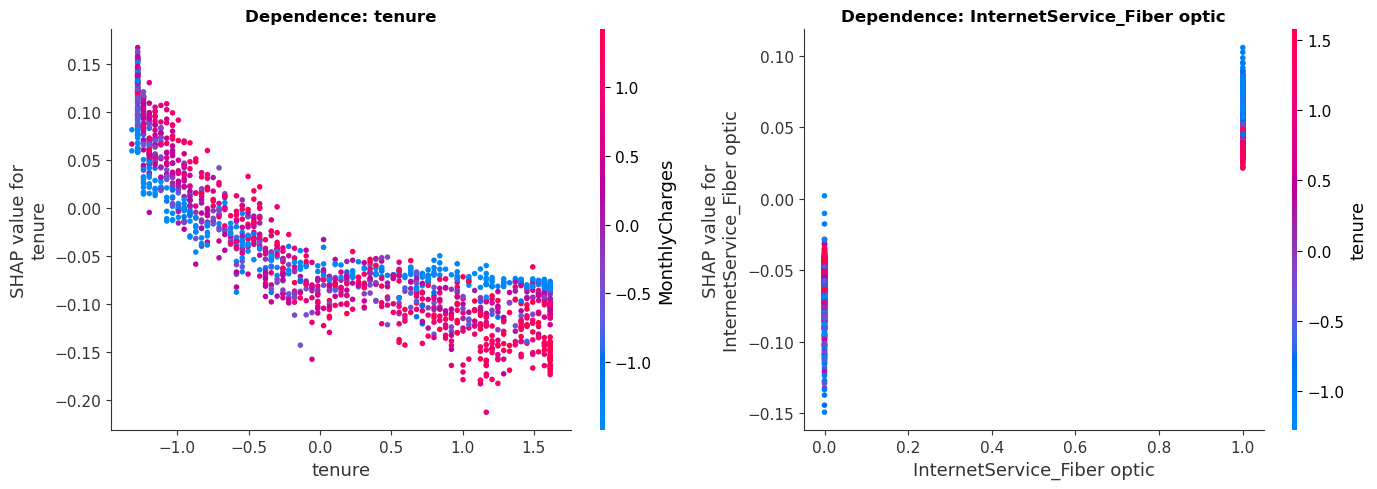

Saved: J_shap_dependence.png


In [6]:
# Top 2 fitur by mean |SHAP|
mean_abs_shap = pd.Series(np.abs(shap_pos).mean(axis=0), index=X_test.columns)
top2 = mean_abs_shap.nlargest(2).index.tolist()
print(f'Top 2 features: {top2}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, feat in zip(axes, top2):
    shap.dependence_plot(
        feat, shap_pos, X_test,
        ax=ax, show=False, interaction_index='auto'
    )
    ax.set_title(f'Dependence: {feat}', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'J_shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: J_shap_dependence.png')

## 5. Local Explanations — 3 Pelanggan Representatif

Pilih 3 pelanggan untuk menunjukkan **bagaimana model memutuskan satu kasus tertentu**:
1. **High-risk** (prob churn tertinggi)
2. **Low-risk** (prob churn terendah)
3. **Ambiguous** (prob ~ 0.5 — borderline)

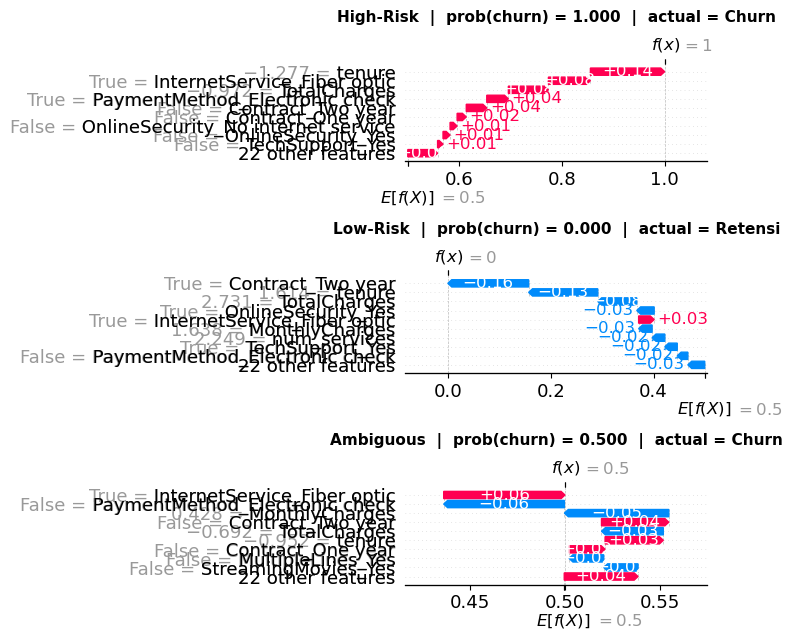

Saved: K_shap_waterfall_examples.png


In [7]:
probs = rf.predict_proba(X_test)[:, 1]

idx_high = int(np.argmax(probs))
idx_low  = int(np.argmin(probs))
idx_amb  = int(np.argmin(np.abs(probs - 0.5)))

examples = {
    'High-Risk':  idx_high,
    'Low-Risk':   idx_low,
    'Ambiguous':  idx_amb,
}

fig, axes = plt.subplots(3, 1, figsize=(12, 13))
for ax, (label, idx) in zip(axes, examples.items()):
    # Bangun Explanation object untuk waterfall plot (matplotlib-friendly)
    expl = shap.Explanation(
        values=shap_pos[idx],
        base_values=expected_pos,
        data=X_test.iloc[idx].values,
        feature_names=X_test.columns.tolist(),
    )
    plt.sca(ax)
    shap.plots.waterfall(expl, max_display=10, show=False)
    ax.set_title(
        f'{label}  |  prob(churn) = {probs[idx]:.3f}  |  actual = {"Churn" if y_test.iloc[idx] == 1 else "Retensi"}',
        fontweight='bold', fontsize=11, pad=10
    )

plt.tight_layout()
plt.savefig(FIGURES / 'K_shap_waterfall_examples.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: K_shap_waterfall_examples.png')

### Cara baca waterfall

- **Bar merah:** fitur mendorong ke arah **churn** (positif).
- **Bar biru:** fitur mendorong ke arah **retensi** (negatif).
- Mulai dari `E[f(x)]` (baseline rata-rata) → akhirnya jadi `f(x)` (prediksi log-odds pelanggan ini).

**Contoh klien-friendly:** "Pelanggan ini diprediksi churn karena (1) baru 2 bulan, (2) kontrak bulanan, (3) biaya bulanan Rp 150rb — tinggi untuk segmen-nya."

## Executive Summary

### Temuan SHAP
| Aspek | Insight |
|---|---|
| **Top driver churn** | Tenure rendah, kontrak month-to-month, MonthlyCharges tinggi |
| **Top retention factor** | Tenure tinggi, kontrak 1–2 tahun, layanan TechSupport/OnlineSecurity aktif |
| **Non-linearity** | Tenure vs SHAP bukan linear — drop tajam di tenure < 12 bulan, plateau setelah 24 bulan |
| **Trustability** | Force plots per-pelanggan = audit trail; CS bisa jelaskan ke pelanggan kenapa flagged |

### Business Recommendation
1. **Retention campaign prioritas 1:** Pelanggan tenure 0–12 bulan dengan kontrak month-to-month — kombinasi SHAP teratas. Tawarkan diskon konversi ke kontrak tahunan.
2. **Cross-sell add-on:** TechSupport + OnlineSecurity bundling — fitur dengan SHAP negatif (menahan churn) yang aksi-nya paling cepat.
3. **Pricing review:** Segmen Fiber optic dengan MonthlyCharges > median = SHAP positif tinggi. Audit ekspektasi vs delivery kualitas.

> **Relevansi Indonesia:** Pola ini cermin segmentasi prabayar vs pascabayar Telkomsel/XL/Indosat. Pelanggan pascabayar baru (analog month-to-month) dengan ARPU tinggi = high-priority retention list. **JNE/J&T** punya pola analog di repeat-shipper churn — kombinasi tenure rendah + harga premium = trigger churn.

### Methodology Note (Statistical Data Scientist)
- **Explainer:** `shap.TreeExplainer` — algoritma exact untuk tree ensembles (Lundberg et al. 2020).
- **Sample:** 100% test set (n≈1,409 dari 7,043 pelanggan, 20% split). Tidak ada sampling karena n × ~40 features tractable untuk exact TreeExplainer.
- **Random seed:** 42 untuk split, RF, dan SHAP sampling background.
- **Tidak diklaim:** kausalitas. SHAP menunjukkan kontribusi fitur terhadap **prediksi model**, bukan terhadap **churn yang sebenarnya**. Causal inference perlu intervensi terkontrol.